In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sklearn
import seaborn as sns

# Data Processing and Visualisation

In [2]:
#Load dataset
iris_data = pd.read_csv('Iris.csv')
iris_data.info()
iris_data.head()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


After loading the dataset, more info about the data is obtained from .info() and .head()
It shows that there is 150 entries with 5 columns (and 1 primary key ['Id'])

In [3]:
#Check for missing data 
'''Function taken from https://www.kaggle.com/code/agilesifaka/step-by-step-iris-ml-project#3.-Explore-data-with-visualization'''
def missing_value_describe(data):
    # check missing values in training data
    missing_value_stats = (data.isnull().sum() / len(data)*100)
    missing_value_col_count = sum(missing_value_stats > 0)
    missing_value_stats = missing_value_stats.sort_values(ascending=False)[:missing_value_col_count]
    print("Number of columns with missing values:", missing_value_col_count)
    if missing_value_col_count != 0:
        # print out column names with missing value percentage
        print("\nMissing percentage (desceding):")
        print(missing_value_stats)
    else:
        print("No missing data")
missing_value_describe(iris_data)

Number of columns with missing values: 0
No missing data


In [4]:
iris_data = iris_data.drop(['Id'], axis=1)
iris_data.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

The function is then used to check if there is any missing data in the entries (there aren't)
Since the Id is just a identifier/primary key, we can drop it to make a more 'streamlined' dataset

In [5]:
#We then check the distribution of each classes
print(iris_data.groupby('Species').size())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64


In [6]:
iris_data.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
iris_data = iris_data.dropna(subset=['Species'])

X = iris_data[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]
Y = iris_data['Species']

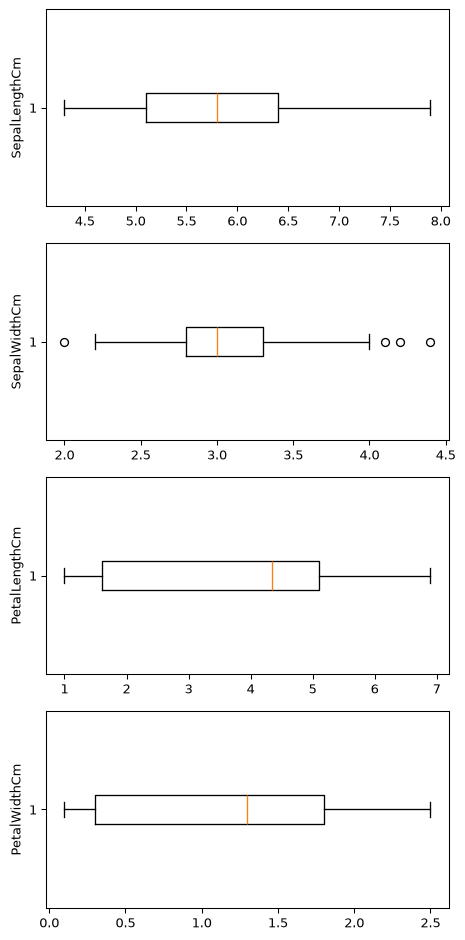

In [8]:
fig, ax = plt.subplots(len(X.columns), 1, figsize=(5, 10), dpi=95)
for i, col in enumerate(X.columns):
    ax[i].boxplot(X[col], orientation='horizontal')
    ax[i].set_ylabel(col)
plt.tight_layout()
plt.show()

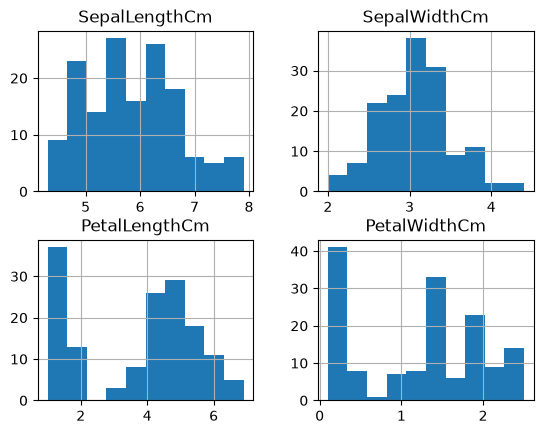

In [9]:
iris_data.hist()
plt.show()

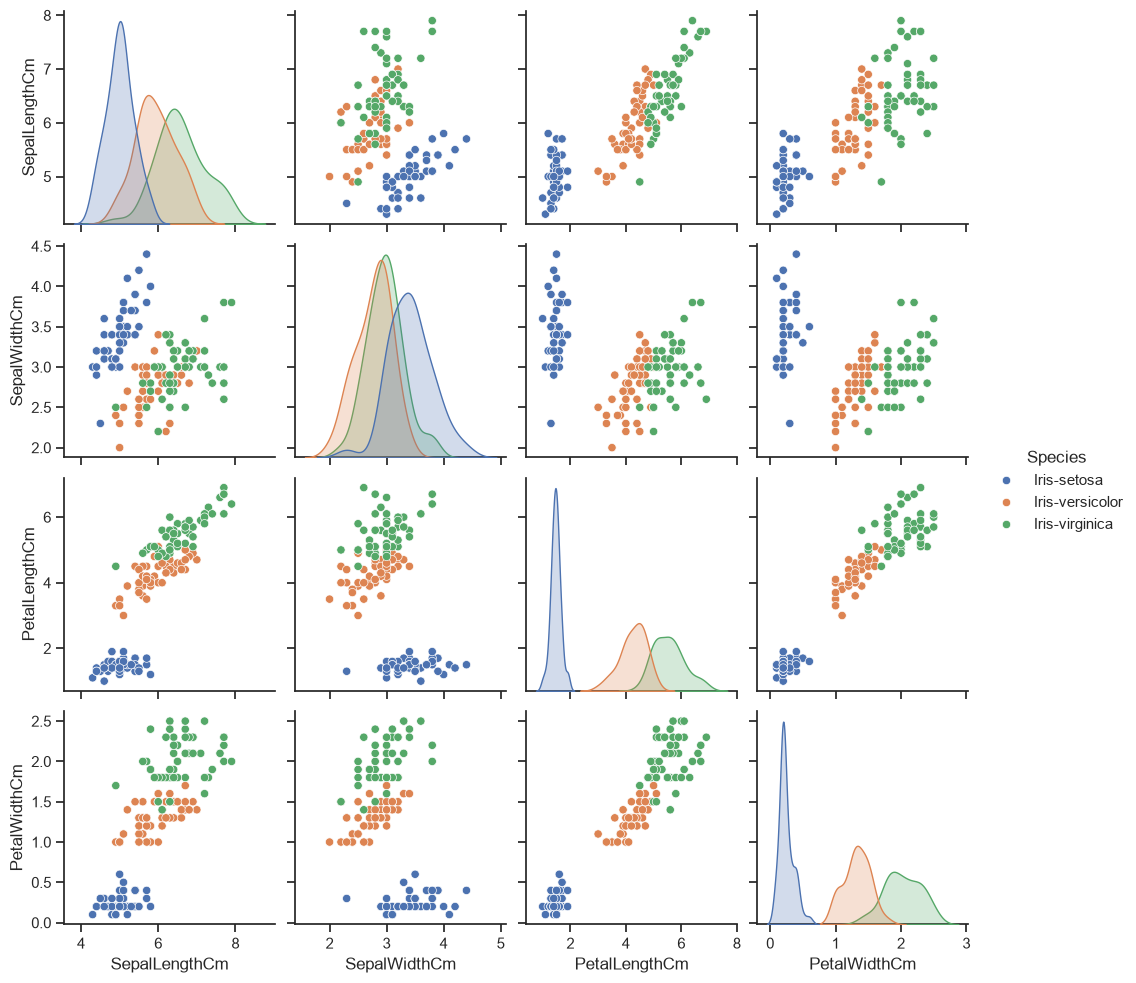

In [10]:
sns.set(style="ticks")
sns.pairplot(iris_data, hue="Species")

The data is then visualised using a boxplot (box and whiskers plot), histogram, and multivariate plot. 
It can be seen from the hisogram that Sepal Length and Width are normal distributions
From the scatter plot, it can be seen that Petal Width and Lengths have the strongest relationship pair-wise.

# Data Modeling

## Decision Tree

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
from sklearn.preprocessing import StandardScaler

In [70]:
d = {'Iris-setosa':0, 'Iris-versicolor':1,'Iris-virginica':2}
Y = Y.map(d)
species = ['setosa','versicolor','virginica']

In [23]:
#Splitting the data into training and testing data (80/20)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state = 27)

In [24]:
#Check shapes
print("X_train.shape:", X_train.shape)
print("X_test.shape:", X_test.shape)
print("Y_train.shape:", X_train.shape)
print("Y_test.shape:", Y_test.shape)

X_train.shape: (105, 4)
X_test.shape: (45, 4)
Y_train.shape: (105, 4)
Y_test.shape: (45,)


## Modelling

In [47]:
#Defining the model
clf = DecisionTreeClassifier(random_state=1)

In [51]:
#Training the model
clf.fit(X_train,Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

Decision Tree Accuracy: 0.9111111111111111


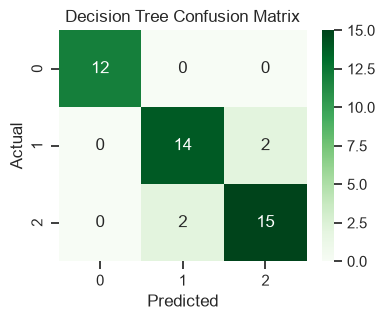

In [53]:
Y_pred = clf.predict(X_test)

accuracy = accuracy_score(Y_test, Y_pred)
cmatrix = confusion_matrix (Y_test, Y_pred)
print(f'Decision Tree Accuracy: {accuracy}')

plt.figure(figsize=(4, 3))
sns.heatmap(cmatrix, annot=True, cmap="Greens", fmt="d")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
#Tuning Hyperparameter
param_grid = {
    'max_depth': range(1, 10, 1),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2, 20, 2),
    'criterion': ["entropy", "gini"]
}

tree = DecisionTreeClassifier(random_state=1)

grid_search = GridSearchCV(estimator=tree, param_grid=param_grid, 
                           cv=5, verbose=True)
grid_search.fit(X_train, Y_train)

print("best accuracy", grid_search.best_score_)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
best accuracy 0.980952380952381
DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1)


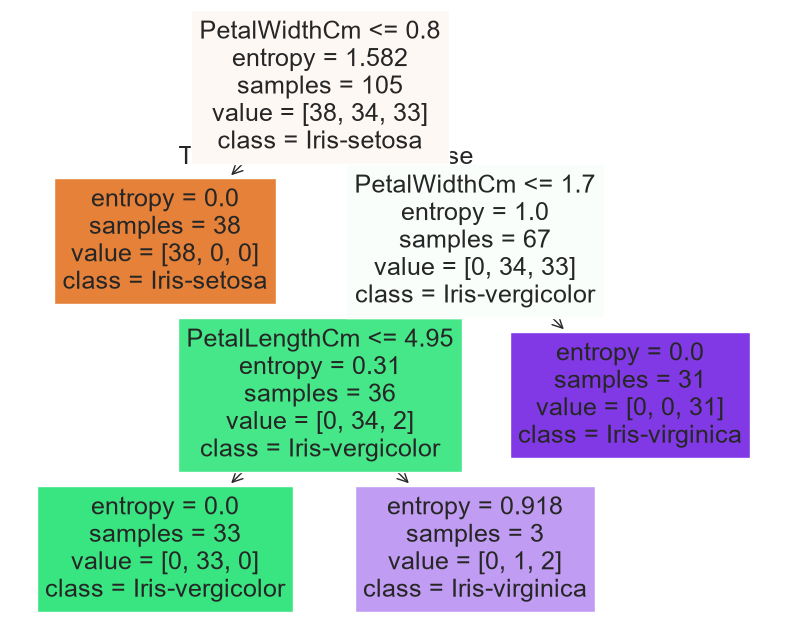

In [44]:
tree_clf = grid_search.best_estimator_

plt.figure(figsize=(10, 8))
plot_tree(tree_clf, filled=True, feature_names=X.columns,class_names=species)
plt.show()

Decision Tree Accuracy: 0.9555555555555556


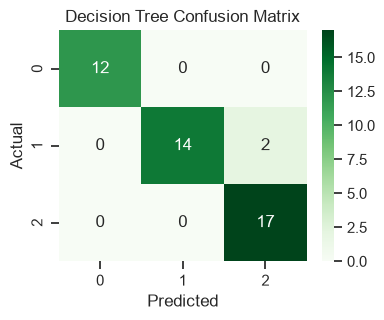

In [57]:
Y_tuned = tree_clf.predict(X_test)

accuracy = accuracy_score(Y_test, Y_tuned)
cmatrix = confusion_matrix (Y_test, Y_tuned)
print(f'Decision Tree Accuracy: {accuracy}')

plt.figure(figsize=(4, 3))
sns.heatmap(cmatrix, annot=True, cmap="Blues", fmt="d")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Random Forest

In [58]:
X,Y

(     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
 0              5.1           3.5            1.4           0.2
 1              4.9           3.0            1.4           0.2
 2              4.7           3.2            1.3           0.2
 3              4.6           3.1            1.5           0.2
 4              5.0           3.6            1.4           0.2
 ..             ...           ...            ...           ...
 145            6.7           3.0            5.2           2.3
 146            6.3           2.5            5.0           1.9
 147            6.5           3.0            5.2           2.0
 148            6.2           3.4            5.4           2.3
 149            5.9           3.0            5.1           1.8
 
 [150 rows x 4 columns],
 0      0
 1      0
 2      0
 3      0
 4      0
       ..
 145    2
 146    2
 147    2
 148    2
 149    2
 Name: Species, Length: 150, dtype: int64)

In [59]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state = 27)

In [62]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [66]:
classifier = RandomForestClassifier(n_estimators=100, random_state=27)
classifier.fit(X_train, Y_train)
Y_pred = classifier.predict(X_test)

Random Forest Accuracy: 0.9


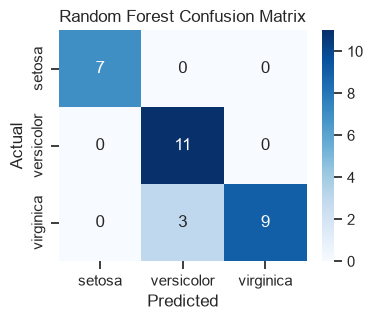

In [71]:
accuracy_rf = accuracy_score(Y_test, Y_pred)
cmatrix_rf = confusion_matrix (Y_test, Y_pred)
print(f'Random Forest Accuracy: {accuracy_rf}')

plt.figure(figsize=(4, 3))
sns.heatmap(cmatrix_rf, annot=True, cmap="Blues", fmt="d",xticklabels=species, yticklabels=species)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Interesting result: Random forest is less accurate than decision tree

**Why?**

- Maybe because the sample size isn't large? In the Iris dataset there is only 150 entries, 80% for training means only 120 entries is used to train the model
- What if I turn down n_estimators?

In [78]:
#n_estimator set at half (50 as opposed to 100)
classifier = RandomForestClassifier(n_estimators=50, random_state=27)
classifier.fit(X_train, Y_train)
Y_pred = classifier.predict(X_test)

Random Forest Accuracy: 0.9333333333333333


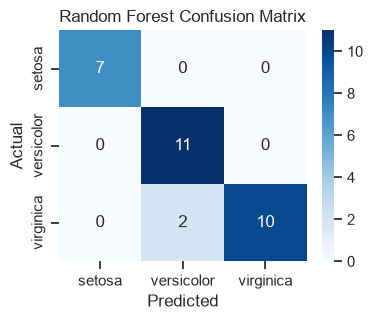

In [79]:
accuracy_rf = accuracy_score(Y_test, Y_pred)
cmatrix_rf = confusion_matrix (Y_test, Y_pred)
print(f'Random Forest Accuracy: {accuracy_rf}')

plt.figure(figsize=(4, 3))
sns.heatmap(cmatrix_rf, annot=True, cmap="Blues", fmt="d",xticklabels=species, yticklabels=species)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [81]:
#Set at a quarter
classifier = RandomForestClassifier(n_estimators=25, random_state=27)
classifier.fit(X_train, Y_train)
Y_pred = classifier.predict(X_test)

Random Forest Accuracy: 0.9333333333333333


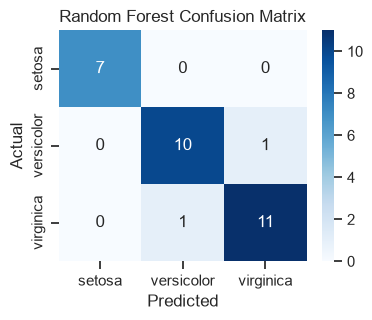

In [82]:
accuracy_rf = accuracy_score(Y_test, Y_pred)
cmatrix_rf = confusion_matrix (Y_test, Y_pred)
print(f'Random Forest Accuracy: {accuracy_rf}')

plt.figure(figsize=(4, 3))
sns.heatmap(cmatrix_rf, annot=True, cmap="Blues", fmt="d",xticklabels=species, yticklabels=species)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Turning down the n_estimator seem to have helped. But there is no significant difference in the accuracy between n_estimator= 50 and 25.

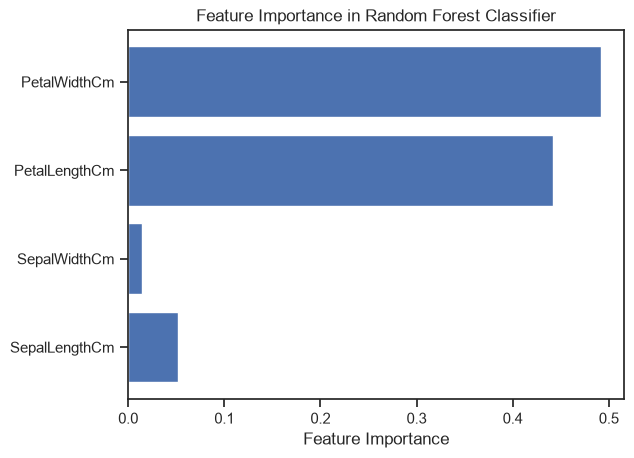

In [84]:
feature_importances = classifier.feature_importances_

plt.barh(X.columns, feature_importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
plt.show()

Petal width seems to be the most important feature in classifying the species, followed by petal length. Sepal width and length does not seem to have that much significance, indicating that the classifier relies on petal measurements to make predictions of the species.